In [1]:
from pathlib import Path 
from IPython.display import display

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import miceforest as mf
import xgboost as xgb

from sklearn.preprocessing import MinMaxScaler 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import classification_report, roc_auc_score

### Data Loading

In [2]:
# Input and output paths
ROOT      = Path().resolve().parent 
RAW       = ROOT / 'data' / 'raw' 
PROCESSED = ROOT / 'data' / 'processed'

## Part One

In [3]:
train_df = pd.read_csv(RAW / 'oil_presence_trainset.csv', keep_default_na=False, na_values=[''])
test_df = pd.read_csv(RAW / 'oil_presence_testset.csv', keep_default_na=False, na_values=[''])

### EDA

In [4]:
print("="*30 + "\n   TRAIN SET FEATURES\n" + "="*30)
display(train_df.info())

print("\n" + "="*30 + "\n   TEST SET FEATURES\n" + "="*30)
display(test_df.info())

   TRAIN SET FEATURES
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  3000 non-null   str    
 1   Porosity                   2197 non-null   float64
 2   Permeability               1814 non-null   float64
 3   Trap_Type                  3000 non-null   str    
 4   Seismic_Score              1950 non-null   float64
 5   Proximity_to_Oil_Field     2057 non-null   float64
 6   Estimated_Reservoir_Depth  1732 non-null   float64
 7   Oil_Presence               3000 non-null   int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 226.5 KB


None


   TEST SET FEATURES
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rock_Type                  2000 non-null   str    
 1   Porosity                   2000 non-null   float64
 2   Permeability               2000 non-null   float64
 3   Trap_Type                  1514 non-null   str    
 4   Seismic_Score              2000 non-null   float64
 5   Proximity_to_Oil_Field     2000 non-null   float64
 6   Estimated_Reservoir_Depth  2000 non-null   int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 133.4 KB


None

In [5]:
print("="*30 + "\n   TRAIN SET FEATURES\n" + "="*30)
display(train_df.describe())

print("\n" + "="*30 + "\n   TEST SET FEATURES\n" + "="*30)
display(test_df.describe())

   TRAIN SET FEATURES


,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
count,2197.000000,1814.000000,1950.000000,2057.000000,1732.000000,3000.000000
mean,14.762194,505.594049,0.490680,2.545868,2764.426674,0.277667
std,8.750759,281.718143,0.286654,1.470783,1288.782908,0.447923
min,0.018825,1.185010,0.000333,0.001007,500.000000,0.000000
25%,7.152815,273.913289,0.245138,1.286000,1650.500000,0.000000
50%,14.602531,504.565289,0.485856,2.550525,2772.500000,0.000000
75%,22.417084,751.803683,0.729728,3.842006,3820.000000,1.000000
max,29.992547,997.134762,0.999353,4.998872,4997.000000,1.000000



   TEST SET FEATURES


,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,15.169888,501.197066,0.497805,2.463405,2744.918000
std,8.576058,291.499605,0.289563,1.433698,1301.672457
min,0.005596,2.130344,0.000009,0.004825,500.000000
25%,7.849880,252.452133,0.245418,1.244396,1630.500000
50%,15.302651,503.000034,0.497128,2.425328,2730.000000
75%,22.569261,750.407433,0.751562,3.708512,3905.750000
max,29.907277,999.707930,0.999695,4.999111,4996.000000


#### Train Set Exploration

In [6]:
# Stratify by rock type and explore missing values

train_df = train_df.copy()

for name, group in train_df.groupby('Rock_Type'):
    print(f'\n{name} - {len(group)} rows')
    missing = group.isnull().mean() * 100 
    print(missing.round(2))


Limestone - 1008 rows
Rock_Type                     0.00
Porosity                     25.10
Permeability                 39.78
Trap_Type                     0.00
Seismic_Score                34.92
Proximity_to_Oil_Field       31.75
Estimated_Reservoir_Depth    43.15
Oil_Presence                  0.00
dtype: float64

Sandstone - 1043 rows
Rock_Type                     0.00
Porosity                     28.67
Permeability                 39.50
Trap_Type                     0.00
Seismic_Score                36.43
Proximity_to_Oil_Field       30.49
Estimated_Reservoir_Depth    43.62
Oil_Presence                  0.00
dtype: float64

Shale - 949 rows
Rock_Type                     0.00
Porosity                     26.45
Permeability                 39.30
Trap_Type                     0.00
Seismic_Score                33.51
Proximity_to_Oil_Field       32.14
Estimated_Reservoir_Depth    39.83
Oil_Presence                  0.00
dtype: float64


In [7]:
# Trap Type Counts

for name, group in train_df.groupby('Rock_Type'):
    print(f"\n{name} — Trap Type counts:")
    print(group['Trap_Type'].value_counts(dropna=False))


Limestone — Trap Type counts:
Trap_Type
Fault        268
None         266
Anticline    259
Dome         215
Name: count, dtype: int64

Sandstone — Trap Type counts:
Trap_Type
Dome         268
Anticline    262
None         259
Fault        254
Name: count, dtype: int64

Shale — Trap Type counts:
Trap_Type
Fault        244
None         242
Anticline    236
Dome         227
Name: count, dtype: int64


In [8]:
# Oil Presence Distribution
for name, group in train_df.groupby('Rock_Type'):
    presence = group['Oil_Presence'].mean() * 100 
    print(f'{name}: {presence:.1f}% oil presence')

Limestone: 36.8% oil presence
Sandstone: 34.9% oil presence
Shale: 10.3% oil presence


#### Test Set Exploration

In [9]:
# Stratify by rock type and explore missing values

test_df = test_df.copy()

for name, group in test_df.groupby('Rock_Type'):
    print(f'\n{name} - {len(group)} rows')
    missing = group.isnull().mean() * 100 
    print(missing.round(2))


Limestone - 632 rows
Rock_Type                     0.00
Porosity                      0.00
Permeability                  0.00
Trap_Type                    24.68
Seismic_Score                 0.00
Proximity_to_Oil_Field        0.00
Estimated_Reservoir_Depth     0.00
dtype: float64

Sandstone - 695 rows
Rock_Type                     0.00
Porosity                      0.00
Permeability                  0.00
Trap_Type                    23.74
Seismic_Score                 0.00
Proximity_to_Oil_Field        0.00
Estimated_Reservoir_Depth     0.00
dtype: float64

Shale - 673 rows
Rock_Type                     0.00
Porosity                      0.00
Permeability                  0.00
Trap_Type                    24.52
Seismic_Score                 0.00
Proximity_to_Oil_Field        0.00
Estimated_Reservoir_Depth     0.00
dtype: float64


In [10]:
# Trap Type Counts

for name, group in test_df.groupby('Rock_Type'):
    print(f"\n{name} — Trap Type counts:")
    print(group['Trap_Type'].value_counts(dropna=False))


Limestone — Trap Type counts:
Trap_Type
Dome         174
NaN          156
Fault        154
Anticline    148
Name: count, dtype: int64

Sandstone — Trap Type counts:
Trap_Type
Dome         195
Anticline    173
NaN          165
Fault        162
Name: count, dtype: int64

Shale — Trap Type counts:
Trap_Type
Dome         179
Fault        170
NaN          165
Anticline    159
Name: count, dtype: int64


In [11]:
# Test set features adjustments
test_df['Trap_Type'] = test_df ['Trap_Type'].fillna('None')
test_df['Estimated_Reservoir_Depth'] = test_df['Estimated_Reservoir_Depth'].astype('float64')

#### Plots

In [12]:
train_df_pt1 = train_df.copy()
test_df_pt1 = test_df.copy()

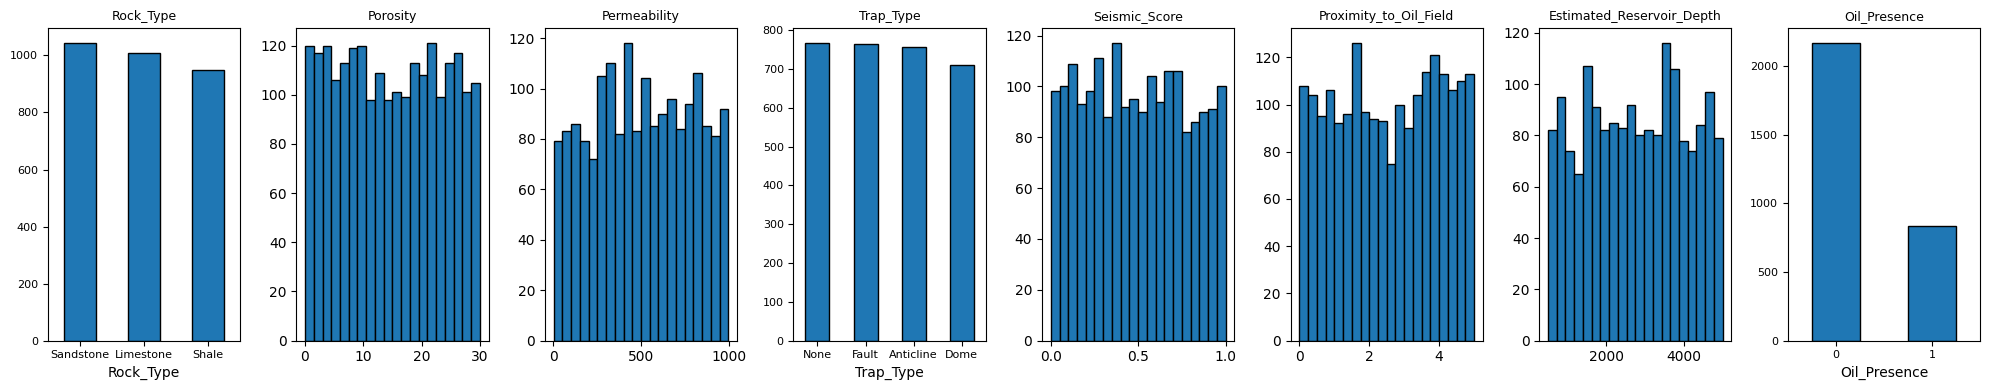

In [13]:
# Data distribution histograms

cols = ['Rock_Type', 'Porosity', 'Permeability', 'Trap_Type','Seismic_Score', 'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth', 'Oil_Presence']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for i, col in enumerate(cols):
    if  col in ['Rock_Type', 'Trap_Type', 'Oil_Presence']:
        train_df_pt1[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black', rot=0, fontsize=8)
    else:
        axes[i].hist(train_df_pt1[col].dropna(), bins=20, edgecolor='black')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()

In [14]:
# Label encode categorical features

train_df_pt1 = pd.get_dummies(train_df_pt1, columns=['Rock_Type', 'Trap_Type'], dtype=int) 
test_df_pt1 = pd.get_dummies(test_df_pt1, columns=['Rock_Type', 'Trap_Type'], dtype=int)

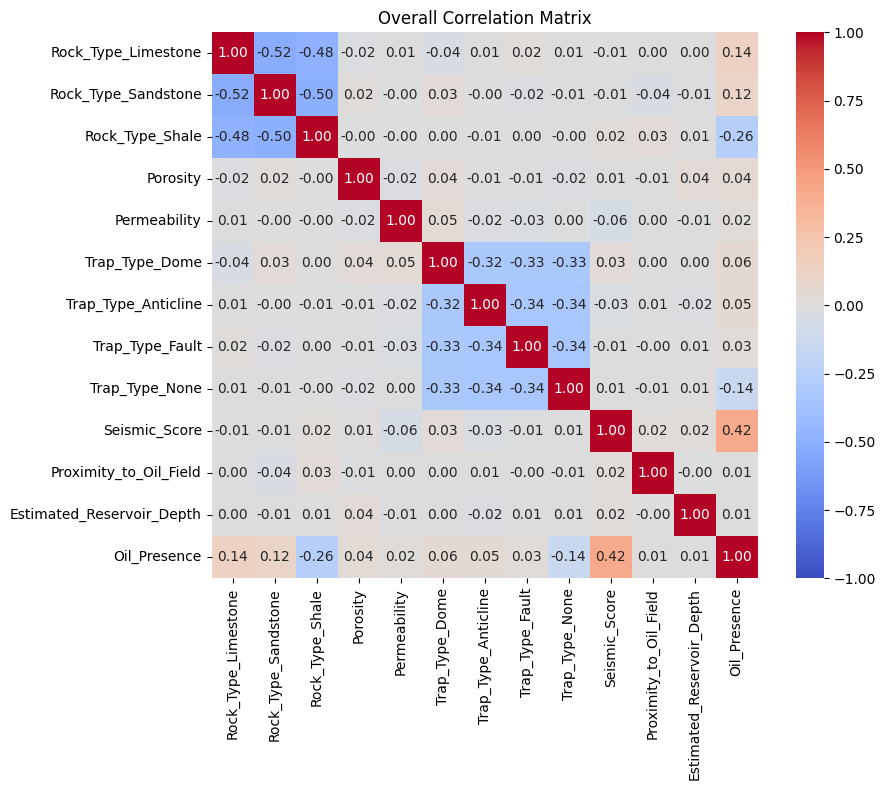

In [15]:
# Correlation heatmap

tot_cols = ['Rock_Type_Limestone', 'Rock_Type_Sandstone','Rock_Type_Shale', 'Porosity', 'Permeability', 'Trap_Type_Dome', 'Trap_Type_Anticline','Trap_Type_Fault', 'Trap_Type_None', 'Seismic_Score', 
            'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth', 'Oil_Presence']

corr = train_df_pt1[tot_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True)
ax.set_title('Overall Correlation Matrix')

plt.tight_layout()
plt.show()

### Train/Validation/Test Split

In [16]:
X = train_df_pt1.drop(columns=['Oil_Presence'])
y = train_df_pt1['Oil_Presence']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)


### Imputation

In [17]:
# MICE via miceforest and Random Forest Classfier

kernel = mf.ImputationKernel(data=X_train, num_datasets=5, random_state=42)
kernel.mice(2)

X_train_completed = kernel.complete_data(dataset=0)
X_val_completed = kernel.impute_new_data(X_val).complete_data(dataset=0) 

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_completed, y_train)

y_pred = rf.predict(X_val_completed)
y_prob = rf.predict_proba(X_val_completed)[:, 1]
print(classification_report(y_val, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob):.3f}')

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       433
           1       0.63      0.61      0.62       167

    accuracy                           0.79       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.79      0.79      0.79       600

ROC-AUC: 0.768


In [18]:
# Iterative Imputer and Xgboost

imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
    random_state=42,
    max_iter=10
)

X_train_completed_v2 = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns
)
X_val_completed_v2 = pd.DataFrame(
    imputer.transform(X_val), columns=X_val.columns
)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()  # handles imbalance
)
xgb_model.fit(X_train_completed_v2, y_train)

y_pred_xgb = xgb_model.predict(X_val_completed_v2)
y_prob_xgb = xgb_model.predict_proba(X_val_completed_v2)[:, 1]

c:\Users\sadar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [19]:
results = {
    'MICE (miceforest) + Random Forest': (y_val, rf.predict(X_val_completed), rf.predict_proba(X_val_completed)[:, 1]),
    'IterativeImputer + XGBoost': (y_val, y_pred_xgb, y_prob_xgb),
}

for name, (true, pred, prob) in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(true, pred))
    print(f"ROC-AUC: {roc_auc_score(true, prob):.3f}")


=== MICE (miceforest) + Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       433
           1       0.63      0.61      0.62       167

    accuracy                           0.79       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.79      0.79      0.79       600

ROC-AUC: 0.768

=== IterativeImputer + XGBoost ===
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       433
           1       0.56      0.55      0.56       167

    accuracy                           0.76       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.75      0.76      0.75       600

ROC-AUC: 0.773


In [20]:
# MICE with CART
imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    max_iter=20,
    random_state=42,
    initial_strategy='median',
    imputation_order='ascending',
    verbose=1
)

X_train_completed = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_completed = pd.DataFrame(
    imputer.transform(X_val), columns=X_val.columns, index=X_val.index
)

print(f"Missing values remaining (train): {X_train_completed.isnull().sum().sum()}")
print(f"Missing values remaining (val): {X_val_completed.isnull().sum().sum()}")

[IterativeImputer] Completing matrix with shape (2400, 12)
[IterativeImputer] Change: 2616.465804041368, scaled tolerance: 4.997 
[IterativeImputer] Change: 4594.777693354462, scaled tolerance: 4.997 
[IterativeImputer] Change: 4328.744318996144, scaled tolerance: 4.997 
[IterativeImputer] Change: 4581.536564912154, scaled tolerance: 4.997 
[IterativeImputer] Change: 4352.852250856, scaled tolerance: 4.997 
[IterativeImputer] Change: 4138.658111511083, scaled tolerance: 4.997 
[IterativeImputer] Change: 4237.333333333334, scaled tolerance: 4.997 
[IterativeImputer] Change: 4180.0908872845, scaled tolerance: 4.997 
[IterativeImputer] Change: 4398.645744290659, scaled tolerance: 4.997 
[IterativeImputer] Change: 4171.5, scaled tolerance: 4.997 
[IterativeImputer] Change: 3746.6782145913335, scaled tolerance: 4.997 
[IterativeImputer] Change: 4393.38377776757, scaled tolerance: 4.997 
[IterativeImputer] Change: 4070.303256916204, scaled tolerance: 4.997 
[IterativeImputer] Change: 4925.05

c:\Users\sadar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [21]:
imputer_variants = {
    'BayesianRidge (default)': BayesianRidge(),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=50, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42),
}

results = {}

for name, estimator in imputer_variants.items():
    imp = IterativeImputer(estimator=estimator, max_iter=20, random_state=42)
    X_train_imp = pd.DataFrame(imp.fit_transform(X_train), columns=X_train.columns)
    X_val_imp = pd.DataFrame(imp.transform(X_val), columns=X_val.columns)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train_imp, y_train)
    
    y_pred = model.predict(X_val_imp)
    y_prob = model.predict_proba(X_val_imp)[:, 1]
    
    results[name] = {
        'accuracy': (y_pred == y_val).mean(),
        'roc_auc': roc_auc_score(y_val, y_prob)
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_val, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_val, y_prob):.3f}")


=== BayesianRidge (default) ===
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       433
           1       0.61      0.61      0.61       167

    accuracy                           0.78       600
   macro avg       0.73      0.73      0.73       600
weighted avg       0.78      0.78      0.78       600

ROC-AUC: 0.794


c:\Users\sadar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



=== DecisionTree ===
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       433
           1       0.67      0.62      0.64       167

    accuracy                           0.81       600
   macro avg       0.76      0.75      0.76       600
weighted avg       0.80      0.81      0.81       600

ROC-AUC: 0.793


c:\Users\sadar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



=== ExtraTrees ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       433
           1       0.66      0.58      0.62       167

    accuracy                           0.80       600
   macro avg       0.76      0.73      0.74       600
weighted avg       0.80      0.80      0.80       600

ROC-AUC: 0.777


c:\Users\sadar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



=== RandomForest ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       433
           1       0.65      0.58      0.61       167

    accuracy                           0.80       600
   macro avg       0.75      0.73      0.74       600
weighted avg       0.79      0.80      0.79       600

ROC-AUC: 0.777


### Prediction for Part One

In [22]:
X_test = test_df_pt1
X_test_completed = kernel.impute_new_data(X_test).complete_data(dataset=0)
predictions = rf.predict(X_test_completed) 

submission = pd.DataFrame({'Oil_Presence': predictions})
submission.to_csv('TeamName_Prediction_Part1.csv', index=False)
print(f'Saved {len(predictions)} predictions')

Saved 2000 predictions


In [23]:
importances = pd.Series(rf.feature_importances_, index=X_train_completed.columns)
importances = importances.sort_values(ascending=False)
print(importances)

Seismic_Score                0.258890
Porosity                     0.150713
Estimated_Reservoir_Depth    0.139109
Permeability                 0.137481
Proximity_to_Oil_Field       0.137286
Rock_Type_Shale              0.069074
Trap_Type_None               0.027700
Rock_Type_Sandstone          0.023297
Rock_Type_Limestone          0.022727
Trap_Type_Anticline          0.012191
Trap_Type_Fault              0.011252
Trap_Type_Dome               0.010280
dtype: float64


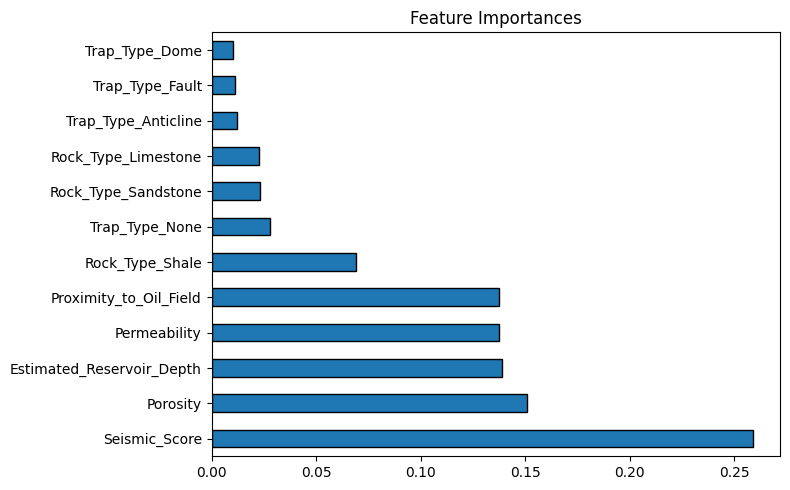

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, edgecolor='black')
ax.set_title('Feature Importances')
plt.tight_layout()
plt.show()

In [25]:
# Reverse one-hot encoding for plotting purposes only
rock_cols = ['Rock_Type_Limestone', 'Rock_Type_Sandstone', 'Rock_Type_Shale']
trap_cols = ['Trap_Type_None', 'Trap_Type_Dome', 'Trap_Type_Anticline', 'Trap_Type_Fault']

plot_df = X_train_completed.copy()
plot_df['Rock_Type'] = pd.from_dummies(plot_df[rock_cols], sep='_').iloc[:, 0]
plot_df['Trap_Type'] = pd.from_dummies(plot_df[trap_cols], sep='_').iloc[:, 0]
plot_df['Rock_Type'] = plot_df['Rock_Type'].str.replace('Type_', '', regex=False)
plot_df['Trap_Type'] = plot_df['Trap_Type'].str.replace('Type_', '', regex=False)

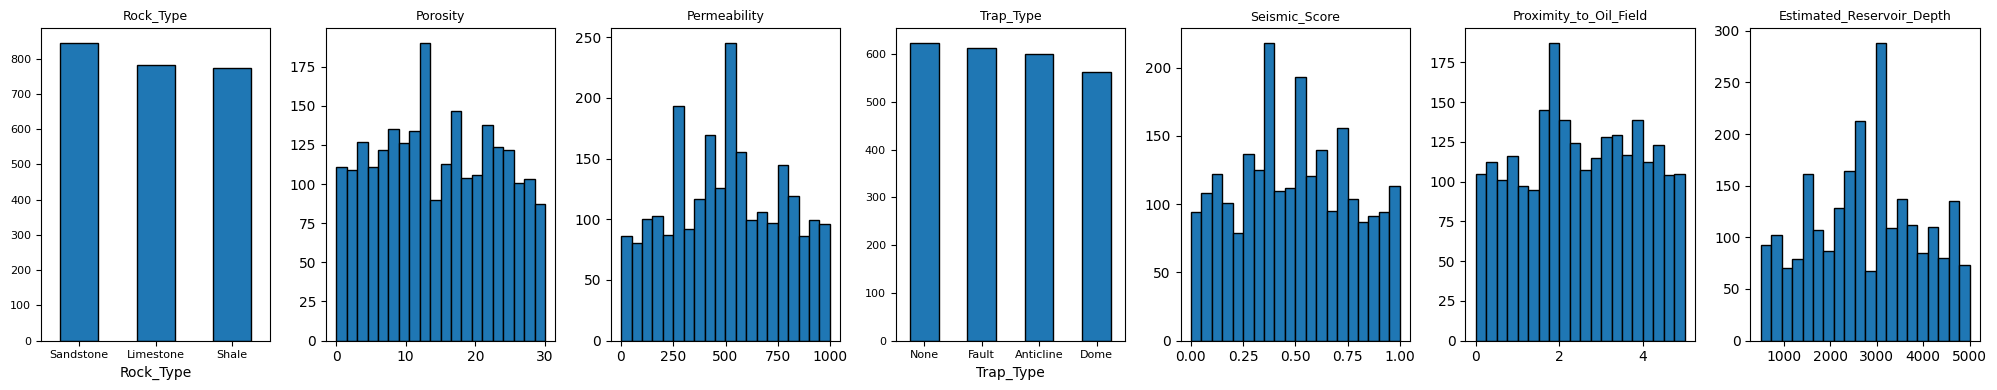

In [26]:
cols = ['Rock_Type', 'Porosity', 'Permeability', 'Trap_Type', 'Seismic_Score',
        'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for i, col in enumerate(cols):
    if col in ['Rock_Type', 'Trap_Type']:
        plot_df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black', rot=0, fontsize=8)
        
    else:
        axes[i].hist(plot_df[col].dropna(), bins=20, edgecolor='black')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()

## Part Two

In [27]:
train_df_pt2 = train_df.copy() 
test_df_pt2 = test_df.copy()

In [28]:
# Porosity and Permeability Distribution Statistics

for name, group in train_df_pt2.groupby('Rock_Type'): 
    print(f'\n{name}')
    print(group[['Porosity', 'Permeability']].describe().round(2))


Limestone
       Porosity  Permeability
count    755.00        607.00
mean      14.55        507.61
std        8.83        278.81
min        0.03          2.37
25%        6.73        280.32
50%       14.22        510.23
75%       22.09        750.23
max       29.98        994.56

Sandstone
       Porosity  Permeability
count    744.00        631.00
mean      15.00        504.69
std        8.65        282.09
min        0.15          1.19
25%        7.59        286.23
50%       15.23        492.22
75%       22.57        755.07
max       29.95        997.13

Shale
       Porosity  Permeability
count    698.00        576.00
mean      14.74        504.46
std        8.78        284.82
min        0.02          2.58
25%        6.82        259.42
50%       14.50        510.96
75%       22.39        746.02
max       29.99        996.68


In [29]:
for name, group in test_df_pt2.groupby('Rock_Type'): 
    print(f'\n{name}')
    print(group[['Porosity', 'Permeability']].describe().round(2))


Limestone
       Porosity  Permeability
count    632.00        632.00
mean      15.30        512.42
std        8.54        293.94
min        0.02          2.31
25%        8.13        261.15
50%       15.38        535.00
75%       22.71        761.94
max       29.81        999.33

Sandstone
       Porosity  Permeability
count    695.00        695.00
mean      14.90        503.33
std        8.47        286.60
min        0.16          2.58
25%        7.72        266.12
50%       15.05        507.64
75%       21.89        743.73
max       29.91        997.96

Shale
       Porosity  Permeability
count    673.00        673.00
mean      15.33        488.45
std        8.73        294.15
min        0.01          2.13
25%        7.79        224.30
50%       15.61        480.05
75%       23.29        739.77
max       29.88        999.71


In [30]:
train_df_pt2 = train_df_pt2.copy().sort_index()

# Check missingness
for col in ['Porosity', 'Permeability', 'Seismic_Score', 'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth']:
    print(train_df.groupby('Rock_Type')[col].apply(lambda x: x.isnull().mean()).round(2), '\n')

Rock_Type
Limestone    0.25
Sandstone    0.29
Shale        0.26
Name: Porosity, dtype: float64 

Rock_Type
Limestone    0.40
Sandstone    0.40
Shale        0.39
Name: Permeability, dtype: float64 

Rock_Type
Limestone    0.35
Sandstone    0.36
Shale        0.34
Name: Seismic_Score, dtype: float64 

Rock_Type
Limestone    0.32
Sandstone    0.30
Shale        0.32
Name: Proximity_to_Oil_Field, dtype: float64 

Rock_Type
Limestone    0.43
Sandstone    0.44
Shale        0.40
Name: Estimated_Reservoir_Depth, dtype: float64 



### Corrections

In [31]:
"""
    Correct porosities and permeabilities for shale and limestone to acceptable ranges
"""

def apply_corrections(df):
    df = df.copy()
    # Shale corrections
    is_shale = df['Rock_Type'].str.upper() == 'SHALE'
    if is_shale.any(): 
        # Rescale shale porosity to (0-10%)
        shale_por = df.loc[is_shale, 'Porosity']
        rescaled_shale_por = (
            (shale_por - shale_por.min()) / (shale_por.max() - shale_por.min()) * (10.0 - 0.01) + 0.01
        )
        df.loc[is_shale, 'Porosity'] = rescaled_shale_por

        # Rescale shale permeability to (0.0001-1.0 mD)
        shale_perm = df.loc[is_shale, 'Permeability']
        rescaled_shale_perm = (
            (shale_perm - shale_perm.min()) / (shale_perm.max() - shale_perm.min()) * (1.0 - 0.0001) + 0.0001
        )
        df.loc[is_shale, 'Permeability'] = rescaled_shale_perm

    # Limestone corrections
    is_limestone = df['Rock_Type'].str.upper() == 'LIMESTONE'
    if is_limestone.any():
        # Rescale limestone permeability to (2-255 mD)
        limestone_perm = df.loc[is_limestone, 'Permeability']
        rescaled_limestone_perm = (
                (limestone_perm - limestone_perm.min()) / (limestone_perm.max() - limestone_perm.min()) * (255.0 - 2.0) + 2.0
            )

        df.loc[is_limestone, 'Permeability'] = rescaled_limestone_perm

    return df

In [32]:
corrected_test_df = apply_corrections(test_df)

for name, group in corrected_test_df.groupby('Rock_Type'):
    print(f"\n{name}")
    print(group[['Porosity', 'Permeability']].describe().round(2))


Limestone


       Porosity  Permeability
count    632.00        632.00
mean      15.30        131.44
std        8.54         74.59
min        0.02          2.00
25%        8.13         67.68
50%       15.38        137.17
75%       22.71        194.76
max       29.81        255.00

Sandstone
       Porosity  Permeability
count    695.00        695.00
mean      14.90        503.33
std        8.47        286.60
min        0.16          2.58
25%        7.72        266.12
50%       15.05        507.64
75%       21.89        743.73
max       29.91        997.96

Shale
       Porosity  Permeability
count    673.00        673.00
mean       5.13          0.49
std        2.92          0.29
min        0.01          0.00
25%        2.61          0.22
50%        5.23          0.48
75%        7.80          0.74
max       10.00          1.00


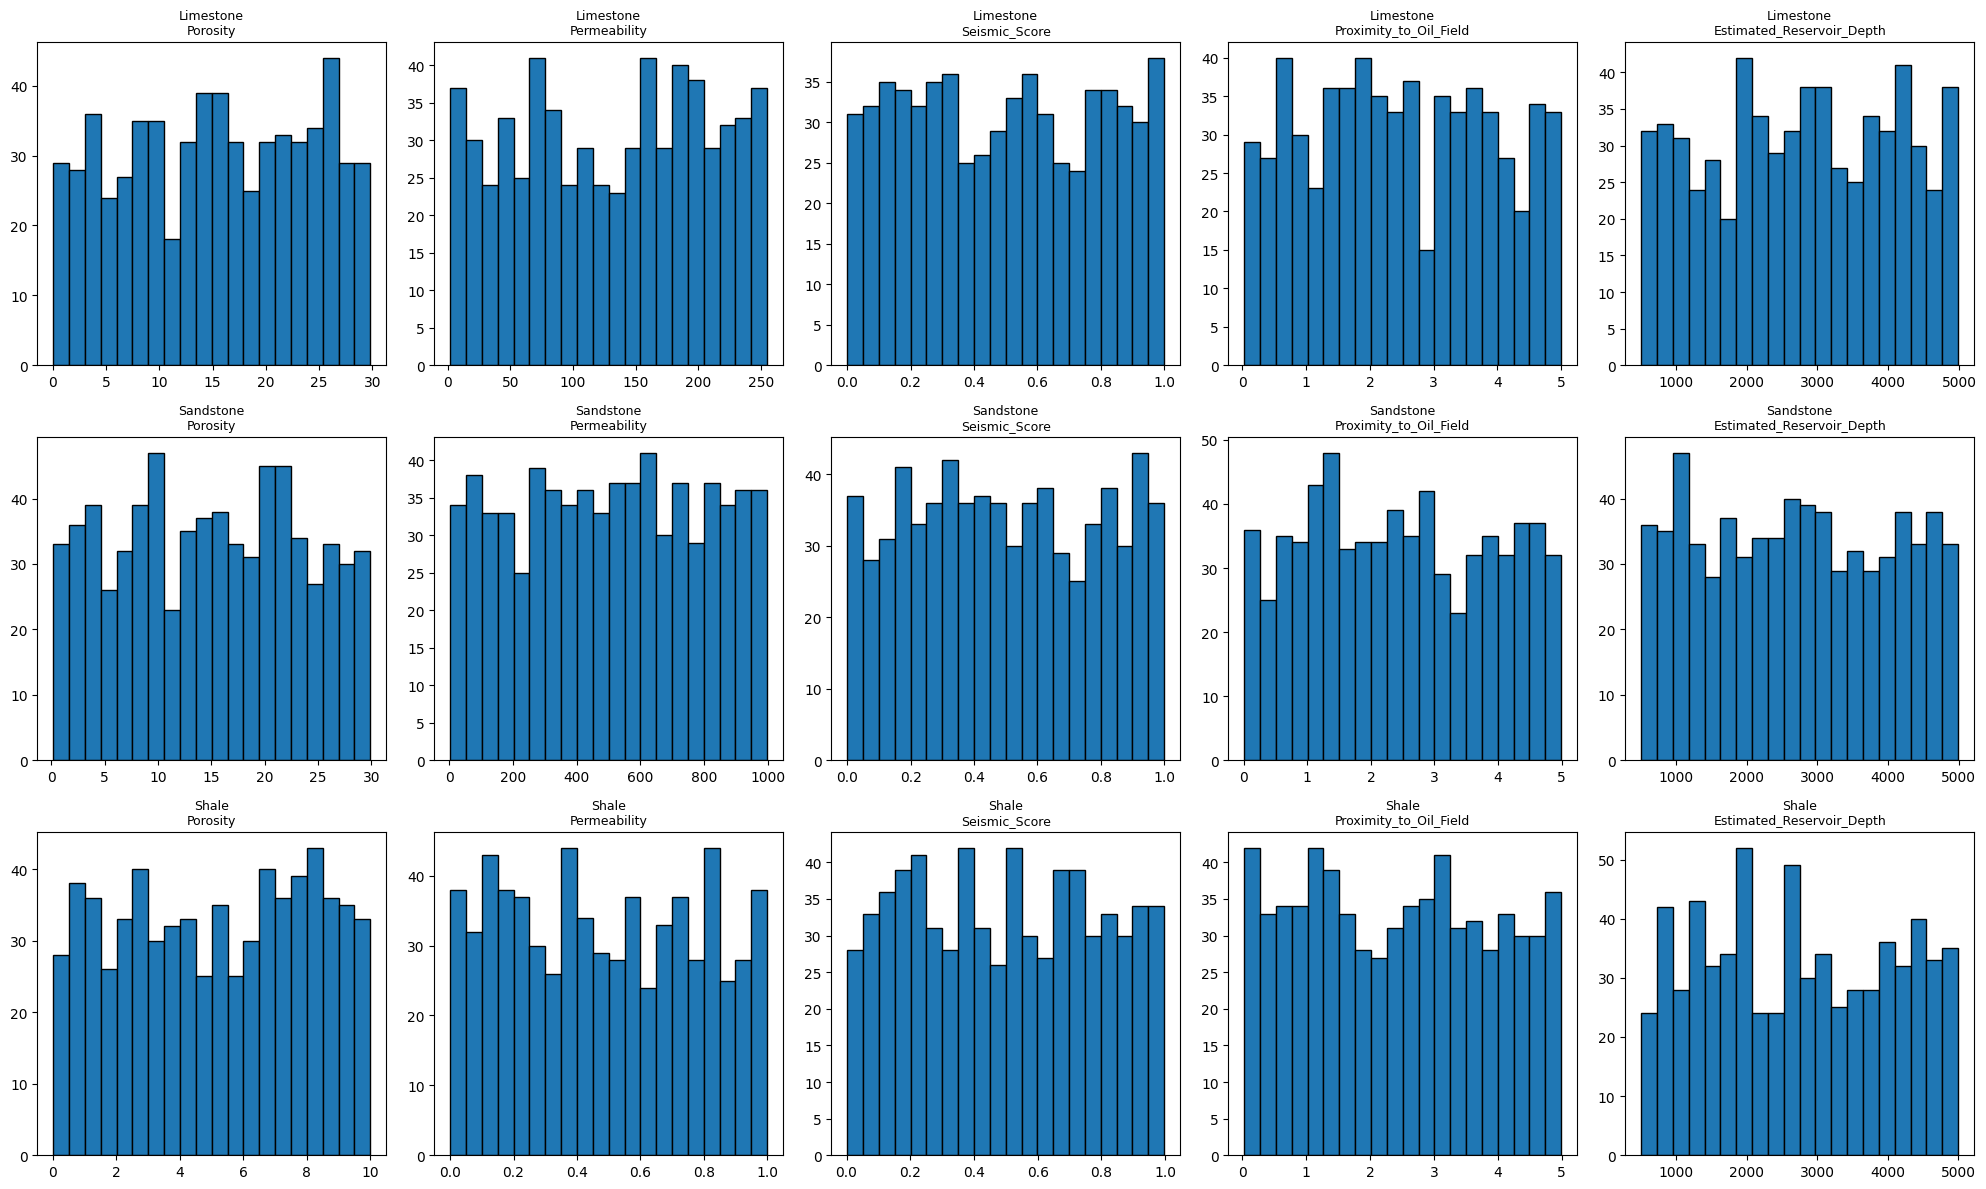

In [33]:
# Histograms after corrections

cols = ['Porosity', 'Permeability', 'Seismic_Score', 'Proximity_to_Oil_Field', 'Estimated_Reservoir_Depth']

groups = list(corrected_test_df.groupby('Rock_Type'))

fig, axes = plt.subplots(len(groups), len(cols), figsize=(20, 4 * len(groups)))

for i, (name, group) in enumerate(groups):
    for j, col in enumerate(cols):
        axes[i, j].hist(group[col].dropna(), bins=20, edgecolor='black')
        axes[i, j].set_title(f'{name}\n{col}', fontsize=9)

plt.tight_layout()

In [34]:
test_df['Trap_Type'] = test_df['Trap_Type'].fillna('None')
test_df = pd.get_dummies(test_df, columns=['Rock_Type'])
test_df['Has_Trap'] = (test_df['Trap_Type'] != 'None').astype(int)

In [35]:
"""
    Correlation heatmaps
"""
groups = list(df_encoded.groupby(df['Rock_Type']))

fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 5))

tot_cols = cols + ['Has_Trap'] + ['Oil_Presence']
for ax, (name, group) in zip(axes, groups):
    corr = group[tot_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm',
                vmin=-1, vmax=1, square=True)
    ax.set_title(f'{name} - Correlation Matrix')

plt.tight_layout()
plt.show()

NameError: name 'df_encoded' is not defined

In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

# Columns for MICE — ordered least missing to most missing
mice_cols = [
    'Rock_Type_enc',             # 0% — anchor
    'Oil_Presence',              # 0% — anchor
    'Trap_Type_enc',             # 0% — anchor
    'Porosity',                  # ~26%
    'Seismic_Score',             # ~35%
    'Proximity_to_Oil_Field',    # ~31%
    'Log_Permeability',          # ~40%
    'Estimated_Reservoir_Depth', # ~43%
]

# MICE with CART — best performer per SPE 218890
imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    max_iter=20,
    random_state=42,
    initial_strategy='median',
    imputation_order='ascending',
    verbose=1
)

# Run MICE on each rock type separately
imputed_frames = []

for rock in ['Sandstone', 'Limestone', 'Shale']:
    mask = df_train_corrected['Rock_Type'] == rock
    group = df_train_corrected[mask][mice_cols].copy()
    
    print(f"\nImputing {rock} — {mask.sum()} rows...")
    imputed_arr = imputer.fit_transform(group)
    imputed_df  = pd.DataFrame(imputed_arr, columns=mice_cols, index=group.index)
    imputed_frames.append(imputed_df)
    print(f"{rock} done ✓")

df_mice = pd.concat(imputed_frames).sort_index()
print(f"\nMICE complete — shape: {df_mice.shape}")
print(f"Missing values remaining:\n{df_mice.isnull().sum()}")

In [ ]:
# Back-transform permeability
df_mice['Permeability'] = np.expm1(df_mice['Log_Permeability'])

# Decode Trap_Type
df_mice['Trap_Type_enc'] = df_mice['Trap_Type_enc'].round().astype(int).clip(
    0, len(le_trap.classes_) - 1
)
df_mice['Trap_Type'] = le_trap.inverse_transform(df_mice['Trap_Type_enc'])

# Decode Rock_Type
df_mice['Rock_Type'] = df_mice['Rock_Type_enc'].round().astype(int).map(
    {0: 'Sandstone', 1: 'Limestone', 2: 'Shale'}
)

# Clip to physical bounds after imputation
df_mice['Porosity'] = df_mice['Porosity'].clip(lower=0.0, upper=30.0)
df_mice['Seismic_Score'] = df_mice['Seismic_Score'].clip(lower=0.0, upper=1.0)
df_mice['Proximity_to_Oil_Field'] = df_mice['Proximity_to_Oil_Field'].clip(lower=0.0, upper=5.0)
df_mice['Estimated_Reservoir_Depth'] = df_mice['Estimated_Reservoir_Depth'].clip(lower=500, upper=5000)
df_mice['Oil_Presence'] = df_mice['Oil_Presence'].round().astype(int).clip(0, 1)

# Re-apply rock-type specific bounds post-imputation
df_mice.loc[df_mice['Rock_Type'] == 'Shale', 'Porosity'] = \
    df_mice.loc[df_mice['Rock_Type'] == 'Shale', 'Porosity'].clip(upper=15.0)
df_mice.loc[df_mice['Rock_Type'] == 'Shale', 'Permeability'] = \
    df_mice.loc[df_mice['Rock_Type'] == 'Shale', 'Permeability'].clip(upper=0.01)
df_mice.loc[df_mice['Rock_Type'] == 'Limestone', 'Permeability'] = \
    df_mice.loc[df_mice['Rock_Type'] == 'Limestone', 'Permeability'].clip(upper=255.0)

# Final clean dataframe
final_cols = ['Rock_Type', 'Porosity', 'Permeability', 'Trap_Type',
              'Seismic_Score', 'Proximity_to_Oil_Field',
              'Estimated_Reservoir_Depth', 'Oil_Presence']

df_train_imputed = df_mice[final_cols].copy()

print("\n=== Final imputed dataset ===")
print(f"Shape: {df_train_imputed.shape}")
print(f"\nMissing values:\n{df_train_imputed.isnull().sum()}")
print(f"\nSample:\n{df_train_imputed.head()}")

In [ ]:
print("\n=== Post-imputation stats by rock type ===")
for rock in ['Sandstone', 'Limestone', 'Shale']:
    subset = df_train_imputed[df_train_imputed['Rock_Type'] == rock]
    print(f"\n{rock}")
    print(subset[['Porosity', 'Permeability']].describe().round(4))